In [1]:
import numpy as np
import re
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
import rasterio
import glob
import os
import utils

from tqdm.notebook import tqdm
tqdm.pandas()

In [2]:
cdi_files = sorted(glob.glob(os.path.join(utils.raw_data_dir, "combined_drought_indicator_2012-2025", "**", "*.tif")))

drought_data_dir = os.path.join(utils.raw_data_dir, "combined_drought_indicator_2012-2025")
cdi_folders = sorted(glob.glob(os.path.join(drought_data_dir, "*")))

LAU_level = False

if LAU_level:
    coverage_files = glob.glob(os.path.join(utils.intermediate_data_dir, "lau_coverage", "*.geojson"))
    out_file = "drought_days_lau.geojson"
else: 
    coverage_files = glob.glob(os.path.join(utils.intermediate_data_dir, "nuts3_coverage", "*.geojson"))
    out_file = "drought_days_nuts3.geojson"

In [ ]:
df = [gpd.read_file(f) for f in coverage_files]
lau_crs = df[0].crs

df = gpd.GeoDataFrame(pd.concat(df, ignore_index=True))
df = df.set_crs(lau_crs)

/var/folders/1_/j9jx95wx4zv29v6wh_ztx5_r0000gp/T/ipykernel_9334/3689449928.py:4: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = gpd.GeoDataFrame(pd.concat(df, ignore_index=True))


In [4]:
with rasterio.open(cdi_files[0]) as src:
    geotiff = src.read(1)
    cdi_dims = src.read(1).shape

    assert(src.crs == lau_crs)
    min_coords = np.array([src.index(x,y) for x,y in df[["xmin", "ymin"]].values.astype(float)])
    max_coords = np.array([src.index(x,y) for x,y in df[["xmax", "ymax"]].values.astype(float)])
    
    
df["row_start"] = min_coords[:,0]
df["col_start"] = min_coords[:,1]
df["row_end"] = max_coords[:,0]
df["col_end"] = max_coords[:,1]
# TODO: verify that we do not have an offset issue here!  



In [5]:

print("cleaning file...")
for col in ["col_start", "col_end", "row_start", "row_end"]:
    df[col] = df[col].astype(int)
    
df["cell_coverage"] = df["cell_coverage"].apply(lambda x: np.array(eval(x)))
    
    
def calculate_cell_weights(cell_coverage):
    # by default, exactextract returns the fraction of each grid cell that is being covered by the polygon.
    # We however desire the inverse: How much of the Polygon's area lies in a given grid cell
    # The latter allows us to weigh grid values to determine the average value inside the LAU
    # NOTE: This simplified computation makes the assumption that all grid cells touching a LAU are of roughly equal size. We should check this assumption for
    # polar regions
    total_coverage = cell_coverage.sum(axis=None)
    return cell_coverage / total_coverage
    
df["cell_weights"] = df["cell_coverage"].apply(calculate_cell_weights)


cleaning file...


In [6]:

warning_days = np.zeros(((2026-2012), cdi_dims[0], cdi_dims[1]))
alert_days = np.zeros(((2026-2012), cdi_dims[0], cdi_dims[1]))


for i, year in enumerate(range(2012,2026)):
    print("processing year: ", year)
    
    year_folder = cdi_folders[i]
    
    assert(bool(re.search(f"{year}01\d\d_{year}12", year_folder))) # I messed this up once before so better be safe
    
    year_files = sorted(glob.glob(os.path.join(year_folder, "*.tif")))
    
    
    yearly_data = np.zeros(shape=(len(year_files), cdi_dims[0], cdi_dims[1]), dtype=np.uint8)
    
    for file_idx, path in enumerate(year_files):
        with rasterio.open(path) as src:
            yearly_data[file_idx] = src.read(1)

    # value 2 corresponds to CDI level "Warning", value 3 corresponds to level "Alert". 
    # See page 3 https://drought.emergency.copernicus.eu/data/factsheets/factsheet_combinedDroughtIndicator_v4.pdf
    cur_year_warning = yearly_data == 2 
    warning_days[i] =  cur_year_warning.sum(axis=0) * 10
    
    cur_year_alert = yearly_data == 3
    alert_days[i] =  cur_year_alert.sum(axis=0) * 10
    

processing year:  2012
processing year:  2013
processing year:  2014
processing year:  2015
processing year:  2016
processing year:  2017
processing year:  2018
processing year:  2019
processing year:  2020
processing year:  2021
processing year:  2022
processing year:  2023
processing year:  2024
processing year:  2025


In [7]:
def calculate_yearly_stats(row):
    cell_weights = row["cell_weights"]
    
    width, height = cell_weights.shape
    
    
    x0, x1 = row["row_start"], row["row_start"]+width
    y0, y1 = row["col_start"], row["col_start"]+height
    
    print()
    print(cell_weights.shape)
    print(row)
    
    warning_days_per_year = (warning_days[:, x0:x1, y0:y1] * cell_weights).sum(axis=(1,2)).round(2)
    alert_days_per_year = (alert_days[:, x0:x1, y0:y1] * cell_weights).sum(axis=(1,2)).round(2)
    
    row["warning_days"] = warning_days_per_year
    row["alert_days"] = alert_days_per_year
    row["drought_days"] = warning_days_per_year + alert_days_per_year
    
    return row   


In [8]:

print("calculating yearly stats...")
df = df.progress_apply(calculate_yearly_stats, axis=1)

out_path = os.path.join(utils.intermediate_data_dir, "drought_days.geojson")
print("writing to: ", out_path)
df.to_file(out_path)

calculating yearly stats...


  0%|          | 0/1338 [00:00<?, ?it/s]


(19, 65)
NUTS_ID                                                      ES120
LEVL_CODE                                                        3
CNTR_CODE                                                       ES
NAME_LATN                                                 Asturias
NUTS_NAME                                                 Asturias
MOUNT_TYPE                                                     1.0
URBN_TYPE                                                        2
COAST_TYPE                                                     1.0
cell_coverage    [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...
xmin                                                     -7.208333
xmax                                                          -4.5
ymin                                                        42.875
ymax                                                     43.666667
geometry         MULTIPOLYGON (((-5.830990009999937 43.64236366...
row_start                                           

In [9]:
for value in ["warning", "alert", "drought"]:
    
    df[f"median_{value}_days"] = df[f"{value}_days"].apply(lambda x: np.median(x).round(2))

In [16]:
if LAU_level: 
    out_data = gpd.GeoDataFrame(df[['GISCO_ID', 'CNTR_CODE', 'LAU_NAME', "geometry", "median_warning_days", "median_alert_days", "median_drought_days"]])
else:
    out_data = gpd.GeoDataFrame(df[['NUTS_ID', 'CNTR_CODE', 'NAME_LATN', 'NUTS_NAME', "geometry", "median_warning_days", "median_alert_days", "median_drought_days"]])

out_data.to_file(os.path.join(utils.intermediate_data_dir, out_file))

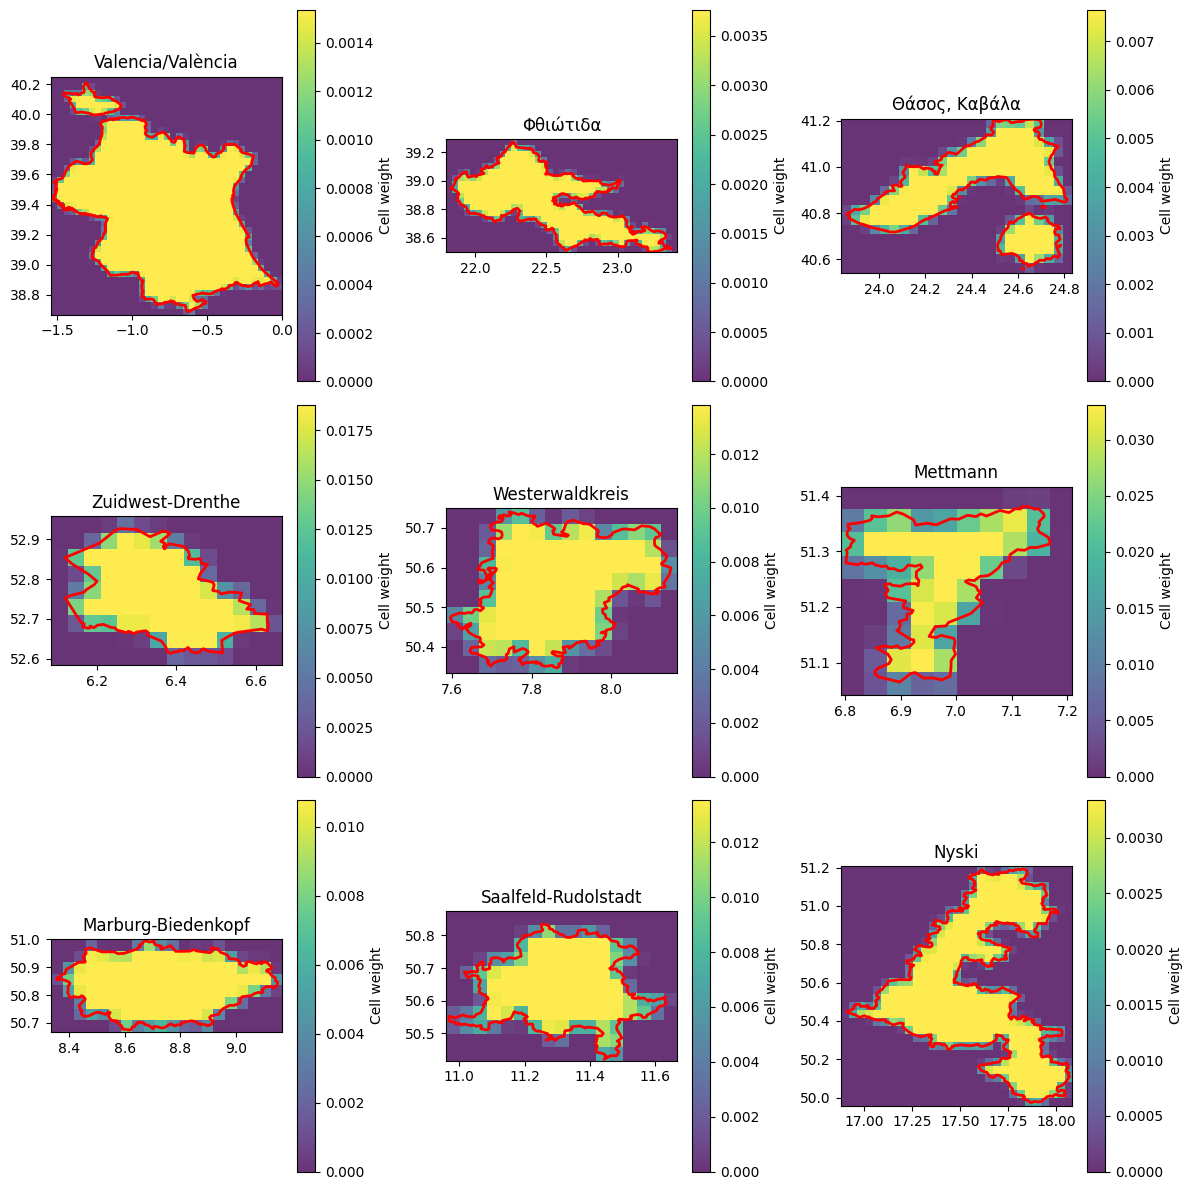

In [15]:
# --- Plot ---
fig, axs = plt.subplots(3,3, figsize=(12, 12), squeeze=True)
axs = axs.flatten()

for i, ax in enumerate(axs):
    temp = df.iloc[np.random.randint(100) + (i*100)]
    col_start = temp["col_start"]
    col_end = temp["col_end"]
    row_start = temp["row_start"]
    row_end = temp["row_end"]

    
    cell_weights = temp["cell_weights"]

    tif_local = geotiff[row_start:row_end, col_start:col_end]
    # 1. Show raster using extent [x_min, x_max, y_min, y_max]
    im = ax.imshow(
        cell_weights,
        extent=[temp["xmin"], temp["xmax"], temp["ymin"], temp["ymax"]],
        cmap="viridis",
        alpha=0.8
    )
    
    gpd.GeoSeries(temp.geometry).plot(ax=ax, facecolor="none", edgecolor="red", linewidth=2)

    
    plt.colorbar(im, ax=ax, label="Cell weight")
    if LAU_level: 

        ax.set_tile(temp["LAU_NAME"])
    else:
        ax.set_title(temp["NUTS_NAME"])
plt.tight_layout()
plt.show()